# Comparación de métodos de estimación de movimiento

En las prácticas se estudian técnicas de movimiento de forma separada.  
Este notebook amplía ese trabajo comparando dos métodos aplicados al mismo vídeo:

- diferencia de imágenes;
- flujo óptico Lucas-Kanade.

La comparación se realiza usando trayectorias y desplazamientos estimados.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Ruta principal del proyecto
project_dir = Path(r"C:\Users\34689\Desktop\Glole\U\masterus\percep")

frame_diff_csv = project_dir / "outputs" / "plots" / "synthetic" / "trajectory_synthetic.csv"
lk_summary_csv = project_dir / "outputs" / "plots" / "synthetic" / "lucas_kanade_summary.csv"

comparison_output = project_dir / "outputs" / "plots" / "method_comparison_synthetic.csv"
trajectory_comparison_plot = project_dir / "outputs" / "plots" / "trajectory_comparison_synthetic.png"
displacement_comparison_plot = project_dir / "outputs" / "plots" / "displacement_comparison_synthetic.png"

print("Frame difference CSV exists:", frame_diff_csv.exists())
print("Lucas-Kanade CSV exists:", lk_summary_csv.exists())

Frame difference CSV exists: True
Lucas-Kanade CSV exists: True


In [ ]:
frame_df = pd.read_csv(frame_diff_csv)
lk_df = pd.read_csv(lk_summary_csv)

print("Frame difference data:")
display(frame_df.head())

print("Lucas-Kanade data:")
display(lk_df.head())

Frame difference data:


,frame,x,y,area
0,0,70,198,757.5
1,1,70,198,1032.5
2,2,73,203,1032.5
3,3,79,207,907.0
4,4,79,212,1032.5


Lucas-Kanade data:


,frame,mean_x,mean_y,mean_dx,mean_dy,mean_displacement,num_points
0,0,61.687590,183.74876,2.000090,3.998771,4.471083,16
1,1,64.685580,188.74869,2.997989,4.999915,5.829849,16
2,2,67.685250,193.74861,2.999667,4.999931,5.830722,16
3,3,70.685425,197.74872,3.000181,4.000103,5.000192,16
4,4,73.684746,202.74892,2.999318,5.000195,5.830768,16


In [ ]:
frame_df = frame_df.sort_values("frame").reset_index(drop=True)

frame_df["dx"] = frame_df["x"].diff()
frame_df["dy"] = frame_df["y"].diff()
frame_df["centroid_displacement"] = np.sqrt(frame_df["dx"]**2 + frame_df["dy"]**2)

frame_df.head()

,frame,x,y,area,dx,dy,centroid_displacement
0,0,70,198,757.5,NaN,NaN,NaN
1,1,70,198,1032.5,0.0,0.0,0.000000
2,2,73,203,1032.5,3.0,5.0,5.830952
3,3,79,207,907.0,6.0,4.0,7.211103
4,4,79,212,1032.5,0.0,5.0,5.000000


In [ ]:
comparison_df = pd.merge(
    frame_df[["frame", "x", "y", "centroid_displacement"]],
    lk_df[["frame", "mean_x", "mean_y", "mean_displacement", "num_points"]],
    on="frame",
    how="inner"
)

comparison_df = comparison_df.rename(columns={
    "x": "frame_difference_x",
    "y": "frame_difference_y",
    "centroid_displacement": "frame_difference_displacement",
    "mean_x": "lucas_kanade_mean_x",
    "mean_y": "lucas_kanade_mean_y",
    "mean_displacement": "lucas_kanade_displacement"
})

comparison_df.to_csv(comparison_output, index=False)

print("Comparison saved at:", comparison_output)
comparison_df.head()

Comparison saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\method_comparison_synthetic.csv


,frame,frame_difference_x,frame_difference_y,frame_difference_displacement,lucas_kanade_mean_x,lucas_kanade_mean_y,lucas_kanade_displacement,num_points
0,0,70,198,NaN,61.687590,183.74876,4.471083,16
1,1,70,198,0.000000,64.685580,188.74869,5.829849,16
2,2,73,203,5.830952,67.685250,193.74861,5.830722,16
3,3,79,207,7.211103,70.685425,197.74872,5.000192,16
4,4,79,212,5.000000,73.684746,202.74892,5.830768,16


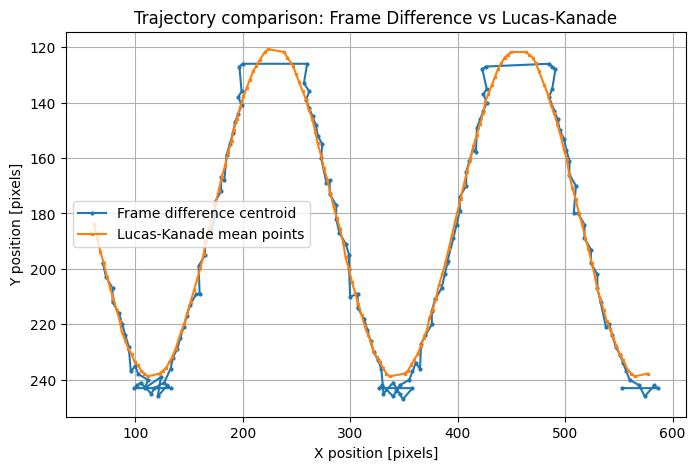

Trajectory comparison plot saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\trajectory_comparison_synthetic.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    comparison_df["frame_difference_x"],
    comparison_df["frame_difference_y"],
    marker="o",
    markersize=2,
    label="Frame difference centroid"
)

plt.plot(
    comparison_df["lucas_kanade_mean_x"],
    comparison_df["lucas_kanade_mean_y"],
    marker="x",
    markersize=2,
    label="Lucas-Kanade mean points"
)

plt.gca().invert_yaxis()
plt.xlabel("X position [pixels]")
plt.ylabel("Y position [pixels]")
plt.title("Trajectory comparison: Frame Difference vs Lucas-Kanade")
plt.legend()
plt.grid(True)
plt.savefig(trajectory_comparison_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Trajectory comparison plot saved at:", trajectory_comparison_plot)

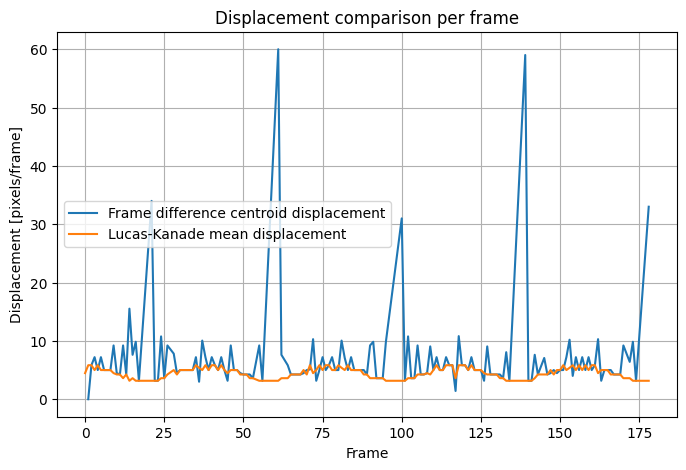

Displacement comparison plot saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\displacement_comparison_synthetic.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    comparison_df["frame"],
    comparison_df["frame_difference_displacement"],
    label="Frame difference centroid displacement"
)

plt.plot(
    comparison_df["frame"],
    comparison_df["lucas_kanade_displacement"],
    label="Lucas-Kanade mean displacement"
)

plt.xlabel("Frame")
plt.ylabel("Displacement [pixels/frame]")
plt.title("Displacement comparison per frame")
plt.legend()
plt.grid(True)
plt.savefig(displacement_comparison_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Displacement comparison plot saved at:", displacement_comparison_plot)

In [ ]:
summary = pd.DataFrame({
    "Method": [
        "Frame difference",
        "Lucas-Kanade"
    ],
    "Mean displacement [px/frame]": [
        comparison_df["frame_difference_displacement"].mean(),
        comparison_df["lucas_kanade_displacement"].mean()
    ],
    "Max displacement [px/frame]": [
        comparison_df["frame_difference_displacement"].max(),
        comparison_df["lucas_kanade_displacement"].max()
    ],
    "Number of frames analyzed": [
        comparison_df["frame_difference_displacement"].count(),
        comparison_df["lucas_kanade_displacement"].count()
    ]
})

summary

,Method,Mean displacement [px/frame],Max displacement [px/frame],Number of frames analyzed
0,Frame difference,6.955036,60.000000,155
1,Lucas-Kanade,4.550083,5.832743,156
